In [ ]:
import operator
from typing import Annotated, List, TypedDict


class QuestionStructureEval(TypedDict):
    score: int
    reasoning: str
    proposal: str


class AbbreviationEval(TypedDict):
    class AbbreviationExpansion(TypedDict):
        abbreviation: str
        expansion: List[str]

    abbreviations: AbbreviationExpansion


class DomainSpecificTermEval(TypedDict):
    domain_terms: List[str]
    proposal: str = "Replace with synonyms or longer explanations"


class KeywordEval(TypedDict):
    class KeywordExpansion(TypedDict):
        keyword: str
        expanded_keywords: List[str]  # Fuzz & Expand

    keywords: List[KeywordExpansion]


class OpenClosedEval(TypedDict):
    reasoning: str
    proposal: str


class EvaluationResult(TypedDict):
    question_structure_eval: QuestionStructureEval
    abbreviations_eval: AbbreviationEval
    domain_specific_term_eval: DomainSpecificTermEval
    keyword_eval: KeywordEval
    open_closed_eval: OpenClosedEval


class RefinementResult(TypedDict):
    intention_score: int
    similarity_score: int
    refined_question: str


class State(TypedDict):
    class Refinement(TypedDict):
        evaluation_results: Annotated[EvaluationResult, operator.add]
        refined_question_results: List[RefinementResult]

    # original_question: Annotated[str, operator.add]
    original_question: str
    refinements: List[Refinement]

In [45]:
class EvaluationResultQuestion(TypedDict):
    question_structure_eval: QuestionStructureEval
    abbreviations_eval: AbbreviationEval
    domain_specific_term_eval: DomainSpecificTermEval
    keyword_eval: KeywordEval
    open_closed_eval: OpenClosedEval
    question: str


class InitialState(TypedDict):
    question: str
    type_of_question: bool  # either refined or original question


class OverallState(TypedDict):
    original_question: str
    evaluation_results: EvaluationResult
    refined_question_eval: Annotated[list[RefinementResult], operator.add]
    refined_questions: Annotated[list[str], operator.add]


class RefinementQuestionInput(TypedDict):
    refined_question: str
    original_question: str

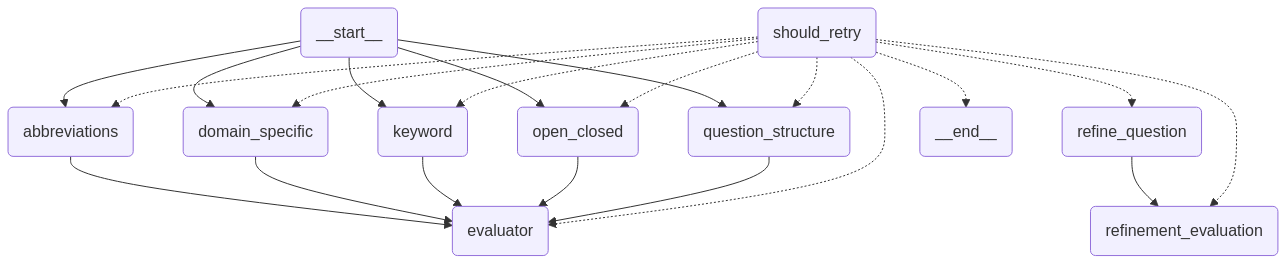

In [56]:
from langgraph.types import Send, Command
from agents.state import QuestionStructureEval, State
from langgraph.graph import END, StateGraph, START
from datetime import datetime


def question_structure(state: InitialState) -> EvaluationResultQuestion:
    question_structure: QuestionStructureEval = {
        "proposal": "Updates on NewWater in Singapore",
        "reasoning": "Clarify logical flow",
        "score": 3,
    }
    # print(f"Stage: question_structure, Time: {datetime.now()}")
    # print(state)
    # print("===================")

    return {"question_structure_eval": question_structure}


def abbreviations(state: InitialState) -> EvaluationResultQuestion:
    abbreviation = {
        "abbreviation": "NWS",
        "expansion": ["New Water Service"],
    }
    # print(f"Stage: abbreviations, Time: {datetime.now()}")
    # print(state)
    # print("===================")
    return {"abbreviations_eval": list(abbreviation)}


def domain_specific(state: InitialState) -> EvaluationResultQuestion:
    domain_results = {
        "domain_terms": ["new water"],
        "proposal": "Replace with synonyms or longer explanations",
    }
    # print(f"Stage: domain_specific, Time: {datetime.now()}")
    # print(state)
    # print("===================")
    return {"domain_specific_term_eval": domain_results}


def keyword(state: InitialState) -> EvaluationResultQuestion:
    keyword_results = {
        "keyword": "new water",
        "expanded_keywords": ["new water", "xing shui"],
    }
    # print(f"Stage: keyword, Time: {datetime.now()}")
    # print(state)
    # print("===================")
    return {"keyword_eval": [keyword_results]}


def open_closed(state: InitialState) -> EvaluationResultQuestion:
    open_closed_results = {
        "proposal": "Be more specific and narrow",
        "reasoning": "Too broad, recall may be low",
    }
    # state["refinements"][-1]["evaluation_results"]["open_closed"] = open_closed_results
    # print(f"Stage: open_closed, Time: {datetime.now()}")
    # print(state)
    # print("===================")
    return {"open_closed_eval": open_closed_results}


def evaluator(state: EvaluationResultQuestion):
    print(f"Stage: evaluator, Time: {datetime.now()}")
    print(state)

    if True:
        return Send(
            "refine_question",
            {
                "original_question": state["question"],
                "evaluation_results": {
                    "question_structure_eval": state["question_structure_eval"],
                    "abbreviations_eval": state["abbreviations_eval"],
                    "domain_specific_term_eval": state["domain_specific_term_eval"],
                    "keyword_eval": state["keyword_eval"],
                    "open_closed_eval": state["open_closed_eval"],
                },
            },
        )

    # TODO: If doesn't meet the score
    else:
        return END


def refine_question(state: OverallState) -> OverallState:
    _refined_question = "Provide updates on NewWater requirements in Singapore"
    print(f"Stage: refine_question, Time: {datetime.now()}")
    print(state)
    print("===================")
    return {"refined_questions": [_refined_question]}


def refinement_evaluation(state: OverallState) -> OverallState:
    refinement_question_results = {
        "intention_score": 9,
        "similarity_score": 0.85,
        "refined_question": state["refined_questions"][-1],
    }
    print(f"Stage: refinement_evaluation, Time: {datetime.now()}")
    print(state)
    print("===================")

    # IF score ok, then END
    if (
        refinement_question_results["intention_score"] >= 8
        and refinement_question_results["similarity_score"] <= 0.9
    ):
        return Command(
            update={"refined_question_eval": [refinement_question_results]},
            goto=END,
        )
    # ELSE go back to refine question
    else:
        return Command(
            update={"refined_question_eval": [refinement_question_results]},
            goto=should_retry,
        )
        return Command(
            update=state,
            goto="refine_question",
        )


def should_retry(state: OverallState):
    print("Check if should retry:")
    print(state)
    print("-------------------------")
    if len(state["refined_question_eval"] < 9):
        # return Command(
        #     update=refinement_question_results,
        #     goto=END,
        # )
        return END
    return "refine_question"


from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(InitialState)
builder.add_node("question_structure", question_structure)
builder.add_node("abbreviations", abbreviations)
builder.add_node("keyword", keyword)
builder.add_node("open_closed", open_closed)
builder.add_node("domain_specific", domain_specific)
builder.add_node("refine_question", refine_question)
builder.add_node("refinement_evaluation", refinement_evaluation)
builder.add_node("should_retry", should_retry)
builder.add_node("evaluator", evaluator)

builder.add_edge(START, "question_structure")
builder.add_edge(START, "abbreviations")
builder.add_edge(START, "keyword")
builder.add_edge(START, "open_closed")
builder.add_edge(START, "domain_specific")

builder.add_edge(
    [
        "question_structure",
        "abbreviations",
        "keyword",
        "open_closed",
        "domain_specific",
    ],
    "evaluator",
)
builder.add_edge("refine_question", "refinement_evaluation")
builder.add_conditional_edges("should_retry", should_retry)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [57]:
def initialize_state(original_question: str) -> InitialState:
    """Initializes the State with default values."""
    return {"question": original_question, "type_of_question": True}


state = initialize_state("What is the impact of LoRA on transformer efficiency?")

config = {"configurable": {"thread_id": "1"}}

for s in graph.stream(state, config, stream_mode="values"):
    print("=====Current Stage====")
    print(s)

=====Current Stage====
{'question': 'What is the impact of LoRA on transformer efficiency?', 'type_of_question': True, 'refined_question_eval': [], 'refined_questions': []}
=====Current Stage====
{'question': 'What is the impact of LoRA on transformer efficiency?', 'type_of_question': True, 'refined_question_eval': [], 'refined_questions': [], 'question_structure_eval': {'proposal': 'Updates on NewWater in Singapore', 'reasoning': 'Clarify logical flow', 'score': 3}, 'abbreviations_eval': ['abbreviation', 'expansion'], 'domain_specific_term_eval': {'domain_terms': ['new water'], 'proposal': 'Replace with synonyms or longer explanations'}, 'keyword_eval': [{'keyword': 'new water', 'expanded_keywords': ['new water', 'xing shui']}], 'open_closed_eval': {'proposal': 'Be more specific and narrow', 'reasoning': 'Too broad, recall may be low'}}
Stage: evaluator, Time: 2025-03-22 22:11:39.560979
{'question_structure_eval': {'proposal': 'Updates on NewWater in Singapore', 'reasoning': 'Clarify 